In [1]:
from pathlib import Path
import sys, os, subprocess, zipfile, json

assert (3, 10) <= sys.version_info[:2] <= (3, 12), 'Dùng Python 3.10–3.12 cho bộ thư viện đã pin.'
BUNDLE_PATH = ''  # Kaggle: /kaggle/input/<private-input>/unifashion_week7_colab.zip
WORK = Path('/kaggle/working/unifashion_week7' if Path('/kaggle/working').exists() else '/content/unifashion_week7')
if not BUNDLE_PATH:
    from google.colab import files
    uploaded = files.upload()
    matches = [name for name in uploaded if name.endswith('.zip')]
    assert len(matches) == 1, 'Upload đúng một file unifashion_week7_colab.zip'
    BUNDLE_PATH = matches[0]
WORK.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(BUNDLE_PATH) as archive:
    for member in archive.infolist():
        destination = (WORK / member.filename).resolve()
        assert destination.is_relative_to(WORK.resolve()), 'Unsafe ZIP path'
    archive.extractall(WORK)
os.chdir(WORK)
print('Working directory:', WORK)
subprocess.run(['nvidia-smi'], check=True)


Saving unifashion_week7_colab.zip to unifashion_week7_colab.zip
Working directory: /content/unifashion_week7


CompletedProcess(args=['nvidia-smi'], returncode=0)

In [11]:
subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', 'requirements-unifashion.txt'], check=True)
subprocess.run([sys.executable, '-c', "import torch; print('PyTorch:',torch.__version__); assert torch.cuda.is_available(), 'Enable GPU runtime'; p=torch.cuda.get_device_properties(0); print(p.name, 'VRAM GiB:',p.total_memory/2**30)"], check=True)


CompletedProcess(args=['/usr/bin/python3', '-c', "import torch; print('PyTorch:',torch.__version__); assert torch.cuda.is_available(), 'Enable GPU runtime'; p=torch.cuda.get_device_properties(0); print(p.name, 'VRAM GiB:',p.total_memory/2**30)"], returncode=0)

In [2]:
def run_live(command):
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in process.stdout:
        print(line, end='', flush=True)
    if process.wait():
        raise RuntimeError(f'Command failed with exit code {process.returncode}')

run_live([sys.executable, '-u', 'scripts/download_unifashion.py', '--with-vision'])


Manifest: /content/unifashion_week7/checkpoints/unifashion/download_manifest.json


In [6]:
import sys
import subprocess

subprocess.run([
    sys.executable, "-m", "pip", "install", "--upgrade",
    "-r", "requirements-unifashion.txt"
], check=True)

subprocess.run([
    sys.executable, "-c",
    "import transformers; "
    "print(transformers.__version__, transformers.__file__); "
    "assert transformers.__version__ == '4.36.2'; "
    "from transformers.modeling_utils import apply_chunking_to_forward"
], check=True)

CompletedProcess(args=['/usr/bin/python3', '-c', "import transformers; print(transformers.__version__, transformers.__file__); assert transformers.__version__ == '4.36.2'; from transformers.modeling_utils import apply_chunking_to_forward"], returncode=0)

In [12]:
run_live([sys.executable, '-m', 'pytest', 'tests/test_unifashion_sanity.py', '-q'])
config = json.loads(Path('configs/unifashion_sanity.json').read_text())
audit = json.loads(Path('data/data_audit.json').read_text())
print(json.dumps(config, indent=2))
print('Train:', audit['splits']['train']['selected_rows'], 'Val:', audit['splits']['val']['selected_rows'])
print('Image overlap:', audit['selected_train_val_image_overlap'])
assert audit['selected_train_val_image_overlap'] == 0

....                                                                     [100%]
=============================== warnings summary ===============================
tests/test_unifashion_sanity.py::test_official_forward_backward_and_reload_with_tiny_fixture
  /usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
    _torch_pytree._register_pytree_node(

tests/test_unifashion_sanity.py::test_official_forward_backward_and_reload_with_tiny_fixture
tests/test_unifashion_sanity.py::test_official_forward_backward_and_reload_with_tiny_fixture
  /usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
    _torch_pytree._register_pytree_node(

-- Docs: https://docs.pytest.org/en/stable/how-t

In [9]:
from google.colab import files
from pathlib import Path

uploaded = files.upload()  # Select the updated unifashion_runtime.py
assert set(uploaded) == {"unifashion_runtime.py"}

(Path(WORK) / "src/unifashion_runtime.py").write_bytes(
    uploaded["unifashion_runtime.py"]
)
print("Adapter updated. Rerun cell 5.")

Saving unifashion_runtime.py to unifashion_runtime.py
Adapter updated. Rerun cell 5.


In [17]:
import json
from pathlib import Path

config_path = Path('configs/unifashion_sanity.json')

config_data = json.loads(
    config_path.read_text()
)

config_data['precision'] = 'fp16'

config_path.write_text(
    json.dumps(config_data, indent=2)
)

print("Precision restored to:", config_data['precision'])

Precision restored to: fp16


In [19]:
from pathlib import Path
import json
import re
import py_compile

script_path = WORK / "scripts" / "train_unifashion_sanity.py"
source = script_path.read_text(encoding="utf-8")

# Backup once
backup_path = script_path.with_suffix(".py.before_fp32_patch")
if not backup_path.exists():
    backup_path.write_text(source, encoding="utf-8")

# Allow both fp16 and fp32
old_guard = (
    '    if config["precision"] != "fp16":\n'
    '        raise ValueError("This tested runner uses fp16 CUDA autocast")'
)

new_guard = (
    '    if config["precision"] not in {"fp16", "fp32"}:\n'
    '        raise ValueError("precision must be either fp16 or fp32")'
)

if old_guard in source:
    source = source.replace(old_guard, new_guard)

# Disable torch.autocast when precision == fp32
def patch_autocast(match):
    args = match.group(1)

    if "enabled=" in args:
        return match.group(0)

    return (
        "torch.autocast("
        + args
        + ', enabled=(config["precision"] == "fp16"))'
    )

source, count = re.subn(
    r'torch\.autocast\(([^)]*dtype\s*=\s*torch\.float16[^)]*)\)',
    patch_autocast,
    source,
    flags=re.DOTALL,
)

script_path.write_text(source, encoding="utf-8")

# Verify the edited script is valid Python
py_compile.compile(str(script_path), doraise=True)

print("Autocast locations patched:", count)

# Change experiment to FP32
config_path = WORK / "configs" / "unifashion_sanity.json"

config = json.loads(
    config_path.read_text(encoding="utf-8")
)

config["precision"] = "fp32"

config_path.write_text(
    json.dumps(config, indent=2),
    encoding="utf-8"
)

print("Configured precision:", config["precision"])

print("\nRelevant lines:")
for i, line in enumerate(
    script_path.read_text().splitlines(),
    start=1
):
    if (
        "precision" in line
        or "autocast" in line
        or "clip_grad_norm_" in line
    ):
        print(f"{i}: {line}")

Autocast locations patched: 2
Configured precision: fp32

Relevant lines:
61:         with torch.autocast("cuda", dtype=torch.float16, enabled=(config["precision"] == "fp16")):
84:     if config["precision"] not in {"fp16", "fp32"}:
85:         raise ValueError("precision must be either fp16 or fp32")
143:         with torch.autocast("cuda", dtype=torch.float16, enabled=(config["precision"] == "fp16")):
148:         grad_norm = torch.nn.utils.clip_grad_norm_(trainable, config["max_grad_norm"], error_if_nonfinite=True)


In [21]:
from pathlib import Path
import re
import py_compile

script_path = WORK / "scripts" / "train_unifashion_sanity.py"
source = script_path.read_text(encoding="utf-8")

# --------------------------------------------------
# 1. Add precision parameter to validation_loss()
# --------------------------------------------------

pattern = r'def validation_loss\(([^)]*)\):'

match = re.search(pattern, source)

assert match is not None, \
    "Could not find validation_loss() definition."

args = match.group(1)

if "precision" not in args:
    new_args = args.rstrip() + ", precision"

    source = (
        source[:match.start()]
        + f"def validation_loss({new_args}):"
        + source[match.end():]
    )

    print("validation_loss signature patched.")
else:
    print("validation_loss already has precision.")

# --------------------------------------------------
# 2. Fix autocast INSIDE validation_loss()
# --------------------------------------------------

start = source.find("def validation_loss(")

next_def = source.find("\ndef ", start + 1)

if next_def == -1:
    next_def = len(source)

validation_block = source[start:next_def]

validation_block = validation_block.replace(
    'enabled=(config["precision"] == "fp16")',
    'enabled=(precision == "fp16")'
)

source = (
    source[:start]
    + validation_block
    + source[next_def:]
)

# --------------------------------------------------
# 3. Pass config["precision"] when calling validation_loss()
# --------------------------------------------------

old_call = "validation_loss(model, val_loader, device)"

new_call = (
    'validation_loss('
    'model, val_loader, device, '
    'config["precision"])'
)

if old_call in source:
    count = source.count(old_call)

    source = source.replace(
        old_call,
        new_call
    )

    print(
        "validation_loss calls patched:",
        count
    )

elif new_call in source:
    print(
        "validation_loss calls already patched."
    )

else:
    raise RuntimeError(
        "Could not find validation_loss call."
    )

# --------------------------------------------------
# 4. Save + verify Python syntax
# --------------------------------------------------

script_path.write_text(
    source,
    encoding="utf-8"
)

py_compile.compile(
    str(script_path),
    doraise=True
)

print("\nRelevant lines after fix:")

for i, line in enumerate(
    source.splitlines(),
    start=1
):
    if (
        "def validation_loss" in line
        or "validation_loss(" in line
        or "autocast" in line
    ):
        print(f"{i}: {line}")

print("\nVALIDATION SCOPE FIX: PASSED")

validation_loss signature patched.
validation_loss calls patched: 3

Relevant lines after fix:
56: def validation_loss(model, loader, device, precision):
61:         with torch.autocast("cuda", dtype=torch.float16, enabled=(precision == "fp16")):
133:     before = validation_loss(model, val_loader, device, config["precision"])
143:         with torch.autocast("cuda", dtype=torch.float16, enabled=(config["precision"] == "fp16")):
168:     after = validation_loss(model, val_loader, device, config["precision"])
189:     reloaded = validation_loss(model, val_loader, device, config["precision"])

VALIDATION SCOPE FIX: PASSED


In [24]:
from pathlib import Path
import py_compile

script_path = (
    WORK
    / "scripts"
    / "train_unifashion_sanity.py"
)

source = script_path.read_text(
    encoding="utf-8"
)

needle = (
    '    before = validation_loss('
    'model, val_loader, device, '
    'config["precision"])'
)

insertion = (
    '    if config["precision"] == "fp32":\n'
    '        model = model.float()\n'
    '        print(\n'
    '            "FP32 mode: model converted to float32; "\n'
    '            f"vision dtype={next(model.visual_encoder.parameters()).dtype}; "\n'
    '            f"first model dtype={next(model.parameters()).dtype}"\n'
    '        )\n'
    '\n'
    '    before = validation_loss('
    'model, val_loader, device, '
    'config["precision"])'
)

if insertion in source:
    print("FP32 model-cast patch already present.")

elif needle in source:
    source = source.replace(
        needle,
        insertion,
        1
    )

    script_path.write_text(
        source,
        encoding="utf-8"
    )

    print(
        "Inserted FP32 model cast "
        "before validation."
    )

else:
    raise RuntimeError(
        "Could not find expected validation call."
    )

# Check that our edit did not break Python syntax
py_compile.compile(
    str(script_path),
    doraise=True
)

print("\nRelevant lines:")

for i, line in enumerate(
    script_path.read_text(
        encoding="utf-8"
    ).splitlines(),
    1
):
    if 125 <= i <= 145:
        print(f"{i:03d}: {line}")

print(
    "\nFP32 dtype-consistency patch: PASSED"
)

Inserted FP32 model cast before validation.

Relevant lines:
125:                               num_workers=config["num_workers"], collate_fn=collate)
126:     val_loader = DataLoader(val, batch_size=batch_size, shuffle=False,
127:                             num_workers=config["num_workers"], collate_fn=collate)
128:     trainable = [parameter for parameter in model.parameters() if parameter.requires_grad]
129:     optimizer = torch.optim.AdamW(trainable, lr=config["learning_rate"], betas=tuple(config["betas"]),
130:                                   eps=config["eps"], weight_decay=config["weight_decay"], foreach=False)
131:     scaler = torch.amp.GradScaler("cuda")
132:     initial_probe = model.query_tokens.detach().cpu().clone()
133:     if config["precision"] == "fp32":
134:         model = model.float()
135:         print(
136:             "FP32 mode: model converted to float32; "
137:             f"vision dtype={next(model.visual_encoder.parameters()).dtype}; "
138:             

In [25]:
from datetime import datetime, timezone
import json
import sys

config_path = WORK / "configs" / "unifashion_sanity.json"
config_data = json.loads(config_path.read_text())

print("Configured precision:", config_data["precision"])

assert config_data["precision"] == "fp32"

RUN_DIR = WORK / "reports" / (
    "run_"
    + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
)

run_live([
    sys.executable,
    "-u",
    "scripts/train_unifashion_sanity.py",
    "--data-dir", str(WORK / "data"),
    "--images-dir", str(WORK / "images"),
    "--output", str(RUN_DIR),
])

Configured precision: fp32
Loading official UniFashion domain-pretraining weights
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
{
  "matched_keys": 338,
  "missing_nonvision_keys": [
    "prompt_tokens",
    "Qformer.bert.embeddings.position_ids",
    "Qformer.cls.predictions.bias",
    "Qformer.cls.predictions.transform.dense.weight",
    "Qformer.cls.predictions.transform.dense.bias",
    "Qformer.cls.predictions.transform.LayerNorm.weight",
    "Qformer.cls.predictions.transform.LayerNorm.bias",
    "Qformer.cls.predictions.decoder.wei

Training metrics:
step | loss                 | loss_itc              | loss_itm             | loss_ttc              
-----+----------------------+-----------------------+----------------------+-----------------------
1    | 0.2208067774772644   | 0.07188445329666138   | 0.057333800941705704 | 0.09158852696418762   
2    | 0.2616126239299774   | 0.00237803696654737   | 0.25907406210899353  | 0.00016050104750320315
3    | 0.27161887288093567  | 0.0016784976469352841 | 0.26494601368904114  | 0.0049943579360842705 
4    | 0.5926753878593445   | 0.0018076712731271982 | 0.051900655031204224 | 0.5389670729637146    
5    | 0.9036269187927246   | 0.07659877836704254   | 0.39031803607940674  | 0.4367101192474365    
6    | 0.7174668312072754   | 0.011780663393437862  | 0.0406644232571125   | 0.6650217175483704    
7    | 0.2558152377605438   | 0.010656950064003468  | 0.035557691007852554 | 0.20960059762001038   
8    | 0.27200213074684143  | 0.2566837668418884    | 0.015039314515888691 | 0.000

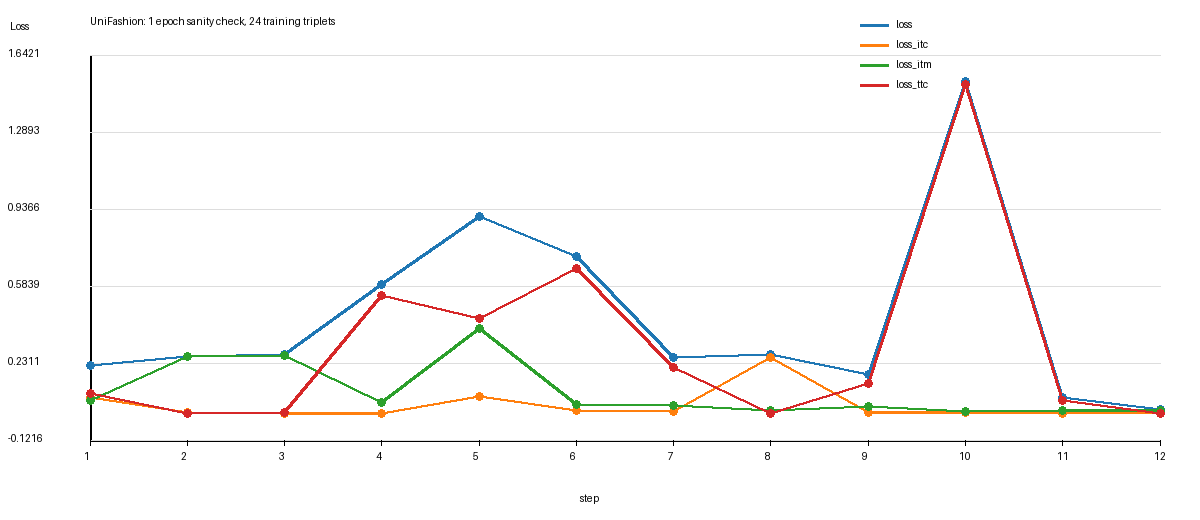

In [28]:
# Cell 6 — read and plot metrics WITHOUT pandas/numpy/matplotlib.
# This keeps the successful training environment unchanged.

import csv
from pathlib import Path
from PIL import Image, ImageDraw
from IPython.display import display

metrics_path = RUN_DIR / "train_metrics.csv"

assert metrics_path.exists(), \
    f"Missing metrics file: {metrics_path}"

with metrics_path.open(
    "r",
    encoding="utf-8",
    newline=""
) as f:
    rows = list(csv.DictReader(f))

assert rows, "train_metrics.csv is empty."

series_names = [
    "loss",
    "loss_itc",
    "loss_itm",
    "loss_ttc",
]

steps = [
    int(float(r["step"]))
    for r in rows
]

series = {
    name: [
        float(r[name])
        for r in rows
    ]
    for name in series_names
}

# --------------------------------------------------
# Print metrics table
# --------------------------------------------------

headers = ["step"] + series_names

widths = {
    h: max(
        len(h),
        max(
            len(str(r.get(h, "")))
            for r in rows
        )
    )
    for h in headers
}

print("Training metrics:")

print(
    " | ".join(
        h.ljust(widths[h])
        for h in headers
    )
)

print(
    "-+-".join(
        "-" * widths[h]
        for h in headers
    )
)

for r in rows:
    print(
        " | ".join(
            str(r.get(h, "")).ljust(
                widths[h]
            )
            for h in headers
        )
    )

# --------------------------------------------------
# Draw the loss curve with Pillow
# --------------------------------------------------

W = 1200
H = 520

LEFT = 90
RIGHT = 40
TOP = 55
BOTTOM = 80

plot_w = W - LEFT - RIGHT
plot_h = H - TOP - BOTTOM

img = Image.new(
    "RGB",
    (W, H),
    "white"
)

draw = ImageDraw.Draw(img)

all_values = [
    value
    for name in series_names
    for value in series[name]
]

y_min = min(all_values)
y_max = max(all_values)

if y_max == y_min:
    y_max = y_min + 1.0

padding = (
    y_max - y_min
) * 0.08

y_min -= padding
y_max += padding

x_min = min(steps)
x_max = max(steps)

if x_max == x_min:
    x_max = x_min + 1

def x_px(step):
    return (
        LEFT
        + (step - x_min)
        / (x_max - x_min)
        * plot_w
    )

def y_px(value):
    return (
        TOP
        + (y_max - value)
        / (y_max - y_min)
        * plot_h
    )

# Axes
draw.line(
    (
        LEFT,
        TOP,
        LEFT,
        TOP + plot_h
    ),
    fill="black",
    width=2
)

draw.line(
    (
        LEFT,
        TOP + plot_h,
        LEFT + plot_w,
        TOP + plot_h
    ),
    fill="black",
    width=2
)

# Horizontal grid + labels
for i in range(6):

    frac = i / 5

    y = (
        TOP
        + frac * plot_h
    )

    value = (
        y_max
        - frac
        * (y_max - y_min)
    )

    draw.line(
        (
            LEFT,
            y,
            LEFT + plot_w,
            y
        ),
        fill="#dddddd",
        width=1
    )

    draw.text(
        (8, y - 8),
        f"{value:.4f}",
        fill="black"
    )

# X-axis labels
for step in steps:

    x = x_px(step)

    draw.line(
        (
            x,
            TOP + plot_h,
            x,
            TOP + plot_h + 5
        ),
        fill="black",
        width=1
    )

    draw.text(
        (
            x - 6,
            TOP + plot_h + 10
        ),
        str(step),
        fill="black"
    )

# Loss lines
line_colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
]

for name, color in zip(
    series_names,
    line_colors
):

    points = [
        (
            x_px(step),
            y_px(value)
        )
        for step, value
        in zip(
            steps,
            series[name]
        )
    ]

    if len(points) >= 2:
        draw.line(
            points,
            fill=color,
            width=3
        )

    for x, y in points:
        radius = 4

        draw.ellipse(
            (
                x - radius,
                y - radius,
                x + radius,
                y + radius
            ),
            fill=color
        )

# Title
draw.text(
    (LEFT, 15),
    (
        "UniFashion: 1 epoch sanity "
        "check, 24 training triplets"
    ),
    fill="black"
)

# Axis labels
draw.text(
    (
        W // 2 - 20,
        H - 28
    ),
    "step",
    fill="black"
)

draw.text(
    (10, 20),
    "Loss",
    fill="black"
)

# Legend
legend_x = (
    LEFT
    + plot_w
    - 300
)

legend_y = 18

for index, (
    name,
    color
) in enumerate(
    zip(
        series_names,
        line_colors
    )
):

    y = (
        legend_y
        + index * 20
    )

    draw.line(
        (
            legend_x,
            y + 7,
            legend_x + 28,
            y + 7
        ),
        fill=color,
        width=3
    )

    draw.text(
        (
            legend_x + 36,
            y
        ),
        name,
        fill="black"
    )

# Save exactly the filename expected by the notebook
loss_curve_path = (
    RUN_DIR
    / "loss_curve.png"
)

img.save(
    loss_curve_path
)

print(
    "\nSaved:",
    loss_curve_path
)

display(img)

In [32]:
import json
import shutil
import zipfile
from pathlib import Path

# --------------------------------------------------
# Reload status from the successful Cell 5 run
# --------------------------------------------------

status_path = RUN_DIR / "status.json"

assert status_path.exists(), \
    f"Missing status file: {status_path}"

status = json.loads(
    status_path.read_text(
        encoding="utf-8"
    )
)

print("Loaded status:")
print(
    json.dumps(
        status,
        indent=2
    )
)

# Confirm that Cell 5 really passed
assert status.get("status") == "sanity_passed", (
    "Training did not finish with sanity_passed: "
    + str(status.get("status"))
)

assert status.get("epoch_completed") is True
assert status.get("reload_verified") is True

print("\nSANITY STATUS VERIFIED")

# --------------------------------------------------
# Create evidence ZIP
# --------------------------------------------------

EVIDENCE = (
    WORK.parent
    / (
        RUN_DIR.name
        + "_evidence.zip"
    )
)

with zipfile.ZipFile(
    EVIDENCE,
    "w",
    zipfile.ZIP_DEFLATED
) as archive:

    # Run outputs
    for path in RUN_DIR.rglob("*"):

        if path.is_file():

            archive.write(
                path,
                "run/"
                + str(
                    path.relative_to(
                        RUN_DIR
                    )
                )
            )

    # Data/audit files
    for path in (
        WORK / "data"
    ).glob("*"):

        if path.is_file():

            archive.write(
                path,
                "data/"
                + path.name
            )

    # Code/config/tests
    for folder in (
        "scripts",
        "src",
        "configs",
        "tests"
    ):

        folder_path = (
            WORK / folder
        )

        if not folder_path.exists():
            continue

        for path in folder_path.rglob("*"):

            if (
                path.is_file()
                and "__pycache__"
                not in path.parts
            ):

                archive.write(
                    path,
                    str(
                        path.relative_to(
                            WORK
                        )
                    )
                )

    requirements_path = (
        WORK
        / "requirements-unifashion.txt"
    )

    if requirements_path.exists():

        archive.write(
            requirements_path,
            "requirements-unifashion.txt"
        )

print(
    "\nEvidence ZIP:",
    EVIDENCE
)

print(
    "Evidence size:",
    f"{EVIDENCE.stat().st_size / 2**20:.2f} MiB"
)

# --------------------------------------------------
# Locate checkpoint from status.json
# --------------------------------------------------

checkpoint_value = status.get(
    "checkpoint"
)

assert checkpoint_value, \
    "status.json does not contain checkpoint path."

checkpoint = Path(
    checkpoint_value
)

# Handle relative paths if needed
if not checkpoint.is_absolute():

    candidate = (
        WORK / checkpoint
    )

    if candidate.exists():
        checkpoint = candidate

assert checkpoint.exists(), (
    f"Checkpoint not found: {checkpoint}"
)

print(
    "Checkpoint:",
    checkpoint,
    f"({checkpoint.stat().st_size / 2**30:.2f} GiB)"
)

# --------------------------------------------------
# Download evidence ZIP
# --------------------------------------------------

if not Path(
    "/kaggle/working"
).exists():

    from google.colab import files

    files.download(
        str(EVIDENCE)
    )

Loaded status:
{
  "status": "sanity_passed",
  "epoch_completed": true,
  "epochs": 1,
  "train_samples": 24,
  "val_samples": 12,
  "optimizer_steps": 12,
  "query_tokens_changed": true,
  "reload_verified": true,
  "validation_before": {
    "loss_itc": 0.6321088243275881,
    "loss_itm": 0.31465688114985824,
    "loss_ttc": 0.32598617625869036
  },
  "validation_after": {
    "loss_itc": 0.5695798658610632,
    "loss_itm": 0.08004992554197088,
    "loss_ttc": 0.20969276574517912
  },
  "validation_reloaded": {
    "loss_itc": 0.5695798658610632,
    "loss_itm": 0.08004992554197088,
    "loss_ttc": 0.20969276574517912
  },
  "peak_cuda_allocated_bytes": 8640484352,
  "checkpoint": "/content/unifashion_week7/checkpoints/run_20260929T164129Z/last.pt",
  "checkpoint_sha256": "d3369accd284953cd2d04f9ad5519ebf3796ac6fe0a20fba3da309442658d5b9",
  "note": "Sanity validation loss only; not FashionIQ Recall@K, not paper reproduction"
}

SANITY STATUS VERIFIED

Evidence ZIP: /content/run_2026

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
# Colab: chạy cell này để lưu checkpoint lớn vào Drive của bạn.
if not Path('/kaggle/working').exists():
    from google.colab import drive
    drive.mount('/content/drive')
    destination = Path('/content/drive/MyDrive/Thesis/UniFashion') / RUN_DIR.name
    destination.mkdir(parents=True, exist_ok=True)
    shutil.copy2(checkpoint, destination / checkpoint.name)
    shutil.copy2(EVIDENCE, destination / EVIDENCE.name)
    print('Saved:', destination)


Mounted at /content/drive
Saved: /content/drive/MyDrive/Thesis/UniFashion/run_20260929T164129Z


## Mẫu báo cáo — chỉ điền sau khi thực sự pass

> Đã tải checkpoint domain-pretraining UniFashion, xác minh SHA-256, nạp 338 tensor tương thích của nhánh retrieval; các head/prompt mới và thành phần generation bị bỏ được liệt kê trong checkpoint_load.json. Đã fine-tune 1 epoch trên 24 triplet FashionIQ train, batch 2, LR 2e-5; hoàn tất [optimizer_steps] bước. Loss và gradient hữu hạn; query tokens đã cập nhật; save/reload checkpoint thành công. Evidence: [đường dẫn commit tới run.log, train_metrics.csv và status.json]. Đây là sanity check; chưa phải benchmark Recall@K hay tái lập kết quả paper.

Sau đó mới chạy fine-tune lớn và đánh giá trên **gallery chính thức theo category**, loại ảnh reference khỏi ranking. FashionIQ test không có target công khai: dùng val hoặc quy trình benchmark chính thức. Baseline hiện có của repo dùng target-only gallery nên cần sửa giao thức trước khi so sánh số liệu.
